In [ ]:
import os, sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

### Please check _common.py for common paths, loaded packages and functions
from _common import *

### Automatic reloading of modules
%load_ext autoreload
%autoreload 2

%matplotlib inline

## Calculate spectrogram

fCWT Package is needed to run the following cells. The final cell directly reads pre-computed results from Data/TA/spectrogram

In [3]:
### Download data ###

# Network and station name
sta_char = ['TA', '645A']

# Time interval for analysis
ts = UTCDateTime(2012,8,24,12)
te = UTCDateTime(2012,9,3,12)
# ts = UTCDateTime(2012,1,1,0)
# te = UTCDateTime(2012,1,11,0)

# Download pressure and/or seismic displacement data
# Instrument response is removed
# For displacement: Positive means downward, corrected based on channel dip angle

# List of channels
channel_list = ['LDF', 'LHZ', 'LHN', 'LHE']

# Download data
stream = Stream()
for channel in channel_list:
    trace, sta_loc = download_trace(sta_char, [ts, te], channel, pre_filt='default', 
                                    extra_portion=2e-3, client=Client("IRIS"))
    stream = stream + trace

# Check number of data points
# (Infrasound LDF channel sometimes have 1 data point less)
stream = check_npts(stream)
print(stream)
del trace

# Info of time series
dt = stream[0].stats.delta
Nt = stream[0].stats.npts
timestamp = stream[0].times('matplotlib')

# Add station location to Stats
stream[0].stats.sta_loc = sta_loc

# Write data to mseed file
# stream.write(os.path.join(data_dir, 'TA/mseeds', f"{'_'.join(sta_char)}.mseed"))


4 Trace(s) in Stream:
TA.645A.EP.LDF | 2012-08-24T11:31:12.971000Z - 2012-09-03T12:28:47.971000Z | 1.0 Hz, 867456 samples
TA.645A..LHZ   | 2012-08-24T11:31:13.000001Z - 2012-09-03T12:28:48.000001Z | 1.0 Hz, 867456 samples
TA.645A..LHN   | 2012-08-24T11:31:13.000000Z - 2012-09-03T12:28:48.000000Z | 1.0 Hz, 867456 samples
TA.645A..LHE   | 2012-08-24T11:31:13.000000Z - 2012-09-03T12:28:48.000000Z | 1.0 Hz, 867456 samples


In [ ]:
### CWT parameters ###

fmin = 1/200        # Min. freq.
fmax = 1/(2*dt)     # Max. freq.
nfreqs = 200        # Freq. samples
w0 = 6.0            # Morlet wavelet parameter (rad/s)
sampling = 'log'    # Sampling method
smooth = True       # Smoothing
ns, nt = 3, 3.0     # Smoothing parameters

# Initialize fCWT
fcwt_obj, morlet_f = fspec.init_fcwt(w0, Nt, nthreads=4, fftw_plan='FFTW_MEASURE')


In [ ]:
### fCWT spectral analysis ###

# Downsampling factor to save spectra
decimate = 120

start_time_fcwt = time.time()

# Pressure & Vertical
psd_P, psd_Z, csd_PZ, coh_PZ, freqs, coi = fspec.my_fxwt(fcwt_obj, morlet_f, stream[0].data, stream[1].data,
                                                         dt, freqmin=fmin, freqmax=fmax, nptsfreq=nfreqs, 
                                                         sampling='log', smooth=smooth, ns=ns, nt=nt)
(psd_P, psd_Z, csd_PZ, coh_PZ, coi) = (psd_P[:, ::decimate], psd_Z[:, ::decimate], 
                                       csd_PZ[:, ::decimate], coh_PZ[:, ::decimate], coi[::decimate])

# Horizontal & Vertical
psd_N, _, csd_NZ, coh_NZ, _, _ = fspec.my_fxwt(fcwt_obj, morlet_f, stream[2].data, stream[1].data,
                                               dt, freqmin=fmin, freqmax=fmax, nptsfreq=nfreqs, 
                                               sampling='log', smooth=smooth, ns=ns, nt=nt)

psd_E, _, csd_EZ, coh_EZ, _, _ = fspec.my_fxwt(fcwt_obj, morlet_f, stream[3].data, stream[1].data,
                                               dt, freqmin=fmin, freqmax=fmax, nptsfreq=nfreqs, 
                                               sampling='log', smooth=smooth, ns=ns, nt=nt)
(psd_N, psd_E, csd_NZ, coh_NZ, csd_EZ, coh_EZ) = (psd_N[:, ::decimate], psd_E[:, ::decimate], 
                                                  csd_NZ[:, ::decimate], coh_NZ[:, ::decimate], 
                                                  csd_EZ[:, ::decimate], coh_EZ[:, ::decimate])

# Pressure & Horizontal
_, _, csd_PN, coh_PN, _, _ = fspec.my_fxwt(fcwt_obj, morlet_f, stream[0].data, stream[2].data,
                                           dt, freqmin=fmin, freqmax=fmax, nptsfreq=nfreqs, 
                                           sampling='log', smooth=smooth, ns=ns, nt=nt)

_, _, csd_PE, coh_PE, _, _ = fspec.my_fxwt(fcwt_obj, morlet_f, stream[0].data, stream[3].data,
                                           dt, freqmin=fmin, freqmax=fmax, nptsfreq=nfreqs, 
                                           sampling='log', smooth=smooth, ns=ns, nt=nt)
csd_PN, coh_PN, csd_PE, coh_PE = (csd_PN[:, ::decimate], coh_PN[:, ::decimate], 
                                  csd_PE[:, ::decimate], coh_PE[:, ::decimate])

# Horizontal & Horizontal
_, _, csd_NE, coh_NE, _, _ = fspec.my_fxwt(fcwt_obj, morlet_f, stream[2].data, stream[3].data,
                                           dt, freqmin=fmin, freqmax=fmax, nptsfreq=nfreqs, 
                                           sampling='log', smooth=smooth, ns=ns, nt=nt)
csd_NE, coh_NE = csd_NE[:, ::decimate], coh_NE[:, ::decimate]

# COI mask
mask_ = (freqs[:, None] < 1/coi)
list_ = [psd_P, psd_Z, psd_N, psd_E, 
         csd_PZ, coh_PZ, csd_NZ, coh_NZ, csd_EZ, coh_EZ, 
         csd_PN, coh_PN, csd_PE, coh_PE, csd_NE, coh_NE]
for i in range(len(list_)):
    list_[i] = np.ma.masked_array(list_[i], mask=mask_)
(psd_P, psd_Z, psd_N, psd_E, 
 csd_PZ, coh_PZ, csd_NZ, coh_NZ, csd_EZ, coh_EZ, 
 csd_PN, coh_PN, csd_PE, coh_PE, csd_NE, coh_NE) = list_
del mask_, list_

end_time_fcwt = time.time()
fcwt_duration = end_time_fcwt - start_time_fcwt
print(f"fCWT execution time: {fcwt_duration:.4f} seconds")

# Save wavelet spectra
_dict = {'freqs': freqs, 'timestamp': timestamp[::decimate], 
         'coi': coi, 'psd_P': psd_P, 'psd_Z': psd_Z, 'psd_N': psd_N, 'psd_E': psd_E,
         'csd_PZ': csd_PZ, 'csd_NZ': csd_NZ, 'csd_EZ': csd_EZ, 'csd_PN': csd_PN,
         'csd_PE': csd_PE, 'csd_NE': csd_NE, 'coh_PZ': coh_PZ, 'coh_NZ': coh_NZ, 
         'coh_EZ': coh_EZ, 'coh_PN': coh_PN,'coh_PE': coh_PE, 'coh_NE': coh_NE}
# np.savez(os.path.join(data_dir, 'TA/spectrogram',  f"{'_'.join(sta_char)}.npz"), **_dict)


fCWT execution time: 268.4726 seconds


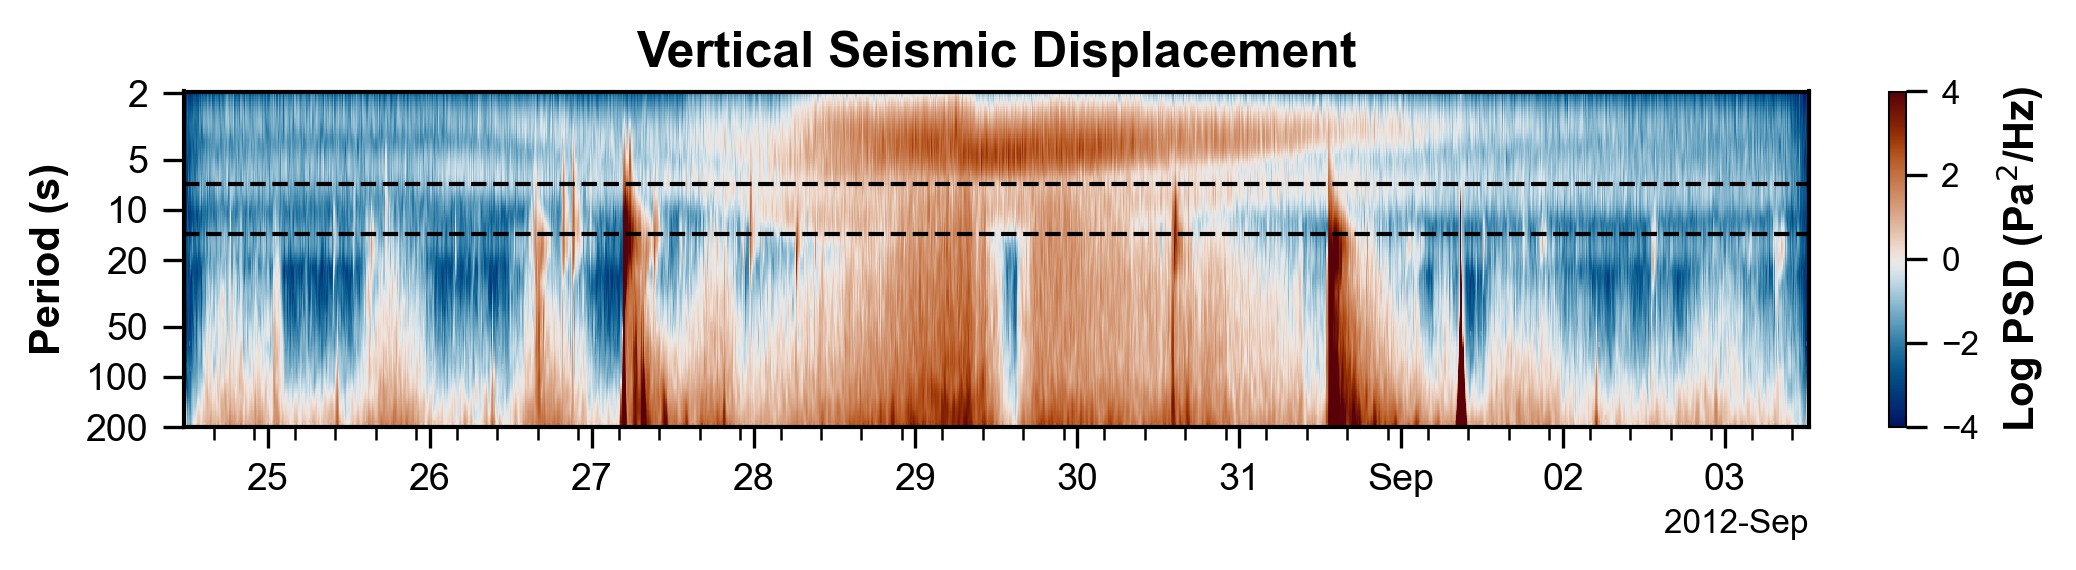

In [ ]:
### Example PSD plot ###

# Read wavelet spectra
_dict = np.load(os.path.join(data_dir, 'TA/spectrogram', "TA_645A.npz"), allow_pickle=True)

fig, ax = plt.subplots(figsize=(7.5, 2))

# Pressure PSD
obj1 = pspec.plot_wt_psd(_dict['timestamp'], _dict['freqs'], _dict['psd_Z'], channel=None, decimate=5,
                         cb_label='Log PSD (Pa$^2$/Hz)', freq_scale='log', value_range=[-4,4], ax=ax)
ax.set_title('Vertical Seismic Displacement')

for val in [1/7, 1/14]:
    ax.axhline(y=val, color='k', linestyle='--', linewidth=1)

period_ticks = [200, 100, 50, 20, 10, 5, 2]
freq_ticks = [1.0/T for T in period_ticks]
minor_locator = mdates.HourLocator(interval=6)

ax.xaxis.set_minor_locator(minor_locator)
ax.set_yticks(freq_ticks)
ax.set_yticklabels([f"{T:.0f}" for T in period_ticks])
ax.set_ylabel("Period (s)")
ax.tick_params(axis='both', which='minor', left=False)
ax.tick_params(axis='both', which='major', labelsize=9)